# Step 3: Feature Engineering (Coarse-Classing)

Coarse-classing for PD model variables using helper functions in `src/pd_feature_engineering.py`.


## Variables Covered

1. Discrete: `grade`, `home_ownership`, `addr_state`, `verification_status`, `purpose`, `initial_list_status`  
2. Continuous: `term_int`, `emp_length_int`, `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `acc_now_delinq`, `mths_since_issue_d`, `int_rate`, `funded_amnt`, `mths_since_earliest_cr_line`, `total_acc`, `total_rev_hi_lim`, `installment`  
3. Continuous with criteria: imbalance (`annual_inc`, `dti_factor/dti`) and null-aware (`mths_since_last_delinq`, `mths_since_last_record`)


In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/src')

import pandas as pd
from pyspark.sql import functions as F
from spark_utils import get_spark_session, save_parquet
from pd_feature_engineering import fit_pd_coarse_classing, plot_by_woe, add_all_bin_indicator_columns


## 3.1 Load Train/Test Data


In [2]:
spark = get_spark_session()

train_path = '/home/jovyan/work/data/parquet/accepted_general_prep_train.parquet'
test_path = '/home/jovyan/work/data/parquet/accepted_general_prep_test.parquet'

train_df = spark.read.parquet(train_path)
test_df = spark.read.parquet(test_path)

print(f'Train rows: {train_df.count()}, columns: {len(train_df.columns)}')
print(f'Test rows: {test_df.count()}, columns: {len(test_df.columns)}')


Spark driver memory: 7g
Train rows: 1809174, columns: 160
Test rows: 451527, columns: 160


## 3.2 Ensure Target Column (`good_bad`)


In [3]:
TARGET_COL = 'good_bad'

if TARGET_COL not in train_df.columns:
    train_df = train_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

if TARGET_COL not in test_df.columns:
    test_df = test_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

train_df.groupBy(TARGET_COL).count().show()


+--------+-------+
|good_bad|  count|
+--------+-------+
|       1|1576506|
|       0| 232668|
+--------+-------+



## 3.3 Run Coarse-Classing Pipelines


In [4]:
train_fe, test_fe, pipelines, reports, name_mapping, missing_vars = fit_pd_coarse_classing(
    train_df,
    test_df,
    target_col=TARGET_COL,
)

print(f'Pipelines fitted: {len(pipelines)}')
print('Mapped business variable -> resolved column:')
for k, v in name_mapping.items():
    print(f'  {k} -> {v}')

if missing_vars:
    print('Missing variables (not found in dataframe):', missing_vars)

print(f'Train engineered columns: {len(train_fe.columns)}')
print(f'Test engineered columns: {len(test_fe.columns)}')


Pipelines fitted: 24
Mapped business variable -> resolved column:
  grade -> grade
  home_ownership -> home_ownership
  addr_state -> addr_state
  verification_status -> verification_status
  purpose -> purpose
  initial_list_status -> initial_list_status
  term_int -> term_int
  emp_length_int -> emp_length_int
  delinq_2yrs -> delinq_2yrs
  inq_last_6mths -> inq_last_6mths
  open_acc -> open_acc
  pub_rec -> pub_rec
  acc_now_delinq -> acc_now_delinq
  mths_since_issue_d -> mths_since_issue_d
  int_rate -> int_rate
  funded_amnt -> funded_amnt
  mths_since_earliest_cr_line -> mths_since_earliest_cr_line
  total_acc -> total_acc
  total_rev_hi_lim -> total_rev_hi_lim
  installment -> installment
  annual_inc -> annual_inc
  dti_factor -> dti
  mths_since_last_delinq -> mths_since_last_delinq
  mths_since_last_record -> mths_since_last_record
Train engineered columns: 232
Test engineered columns: 232


## 3.4 Example Reports


In [5]:
pipelines["acc_now_delinq"].history_

[{'iter': 0,
  'table':    __order__        bin    n_obs  prop_good  prop_n_obs     n_good     n_bad  \
  0          0  (-inf, 0]        7   1.000000    0.000004        7.0       0.0   
  1          1   (0, inf]  1809148   0.871396    0.999986  1576484.0  232664.0   
  2          2    MISSING       19   0.789474    0.000011       15.0       4.0   
  
     prop_n_good  prop_n_bad       WoE  diff_prop_good  diff_WoE  IV_component  \
  0     0.000004    0.000000  8.398680             NaN       NaN  3.729181e-05   
  1     0.999986    0.999983  0.000003        0.128604  8.398676  1.047813e-11   
  2     0.000010    0.000017 -0.591551        0.081922  0.591554  4.541436e-06   
  
           IV  
  0  0.000042  
  1  0.000042  
  2  0.000042  ,
  'small_bins': ['(-inf, 0]', 'MISSING'],
  'close_pairs': [],
  'monotonic_break_pairs': [],
  'suggested_pair': ('(-inf, 0]', '(0, inf]'),
  'stop_reason': 'Small bin detected.'},
 {'iter': 1,
  'table':    __order__          bin    n_obs  prop_good

In [6]:
# WoE/IV table examples
example_feats = [ "annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record" ]
for feat in example_feats:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        print(f'=== {feat} (resolved: {resolved}) ===')
        display(reports[resolved].head(15))


=== annual_inc (resolved: annual_inc) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 39000]",270235,0.846674,0.149369,228801.0,41434.0,0.145132,0.178082,-0.204603,NaN,NaN,0.006742,0.032023
1,1,"(39000, 46000]",175457,0.851776,0.096982,149450.0,26007.0,0.094798,0.111777,-0.164758,0.005101,0.039845,0.002797,0.032023
2,2,"(46000, 52000]",141384,0.857820,0.078148,121282.0,20102.0,0.076931,0.086398,-0.116055,0.006044,0.048703,0.001099,0.032023
3,3,"(52000, 60372]",228318,0.861316,0.126200,196654.0,31664.0,0.124740,0.136091,-0.087088,0.003496,0.028966,0.000988,0.032023
4,4,"(60372, 72000]",212411,0.867945,0.117408,184361.0,28050.0,0.116943,0.120558,-0.030447,0.006628,0.056642,0.000110,0.032023
5,5,"(72000, 77004]",103192,0.875455,0.057038,90340.0,12852.0,0.057304,0.055238,0.036727,0.007511,0.067174,0.000076,0.032023
6,6,"(77004, 90000]",170548,0.878738,0.094268,149867.0,20681.0,0.095063,0.088886,0.067179,0.003282,0.030452,0.000415,0.032023
7,7,"(90000, 100000]",112659,0.885540,0.062271,99764.0,12895.0,0.063282,0.055422,0.132614,0.006802,0.065435,0.001042,0.032023
8,8,"(100000, 130000]",207815,0.894281,0.114867,185845.0,21970.0,0.117884,0.094426,0.221881,0.008741,0.089267,0.005205,0.032023
9,9,"(130000, MISSING]",187155,0.909097,0.103448,170142.0,17013.0,0.107923,0.073121,0.389302,0.014816,0.167421,0.013549,0.032023


=== dti_factor (resolved: dti) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 7.27]",180021,0.902267,0.099505,162427.0,17594.0,0.103030,0.075618,0.309317,NaN,NaN,0.008479,0.040464
1,1,"(7.27, 9.05]",90607,0.899456,0.050082,81497.0,9110.0,0.051695,0.039155,0.277840,0.002811,0.031477,0.003484,0.040464
2,2,"(9.05, 11.89]",180673,0.895197,0.099865,161738.0,18935.0,0.102593,0.081382,0.231612,0.004258,0.046228,0.004913,0.040464
3,3,"(11.89, 13.74]",135650,0.889665,0.074979,120683.0,14967.0,0.076551,0.064328,0.173966,0.005533,0.057646,0.002126,0.040464
4,4,"(13.74, 15.49]",135157,0.884808,0.074706,119588.0,15569.0,0.075856,0.066915,0.125417,0.004857,0.048549,0.001121,0.040464
5,5,"(15.49, 17.24]",135526,0.878370,0.074910,119042.0,16484.0,0.075510,0.070848,0.063732,0.006438,0.061685,0.000297,0.040464
6,6,"(17.24, 18.45]",92176,0.873850,0.050949,80548.0,11628.0,0.051093,0.049977,0.022084,0.004520,0.041649,0.000025,0.040464
7,7,"(18.45, 21.58]",224243,0.866805,0.123948,194375.0,29868.0,0.123295,0.128372,-0.040352,0.007045,0.062436,0.000205,0.040464
8,8,"(21.58, 24.48]",180672,0.856962,0.099864,154829.0,25843.0,0.098210,0.111072,-0.123072,0.009843,0.082720,0.001583,0.040464
9,9,"(24.48, 27.12]",135923,0.847539,0.075130,115200.0,20723.0,0.073073,0.089067,-0.197928,0.009423,0.074856,0.003166,0.040464


=== mths_since_last_delinq (resolved: mths_since_last_delinq) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 19]",257854,0.855352,0.142526,220556.0,37298.0,0.139902,0.160306,-0.136142,NaN,NaN,0.002778,0.005031
1,1,"(19, 34]",211503,0.865770,0.116906,183113.0,28390.0,0.116151,0.122019,-0.049287,0.010418,0.086855,0.000289,0.005031
2,2,"(34, 49]",177630,0.870821,0.098183,154684.0,22946.0,0.098118,0.098621,-0.005113,0.005051,0.044174,0.000003,0.005031
3,3,"(49, inf]",235300,0.868194,0.130059,204286.0,31014.0,0.129581,0.133297,-0.028271,0.002628,0.023158,0.000105,0.005031
4,4,MISSING,926887,0.878065,0.512326,813867.0,113020.0,0.516247,0.485757,0.060878,0.009871,0.089150,0.001856,0.005031


=== mths_since_last_record (resolved: mths_since_last_record) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, inf]",287849,0.843289,0.159105,242740.0,45109.0,0.153973,0.193877,-0.230445,NaN,NaN,0.009196,0.011124
1,1,MISSING,1521325,0.876713,0.840895,1333766.0,187559.0,0.846027,0.806123,0.048315,0.033424,0.278759,0.001928,0.011124


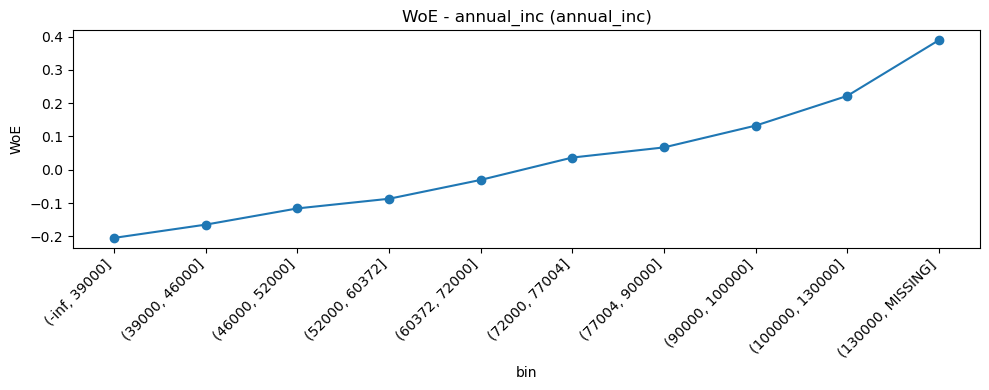

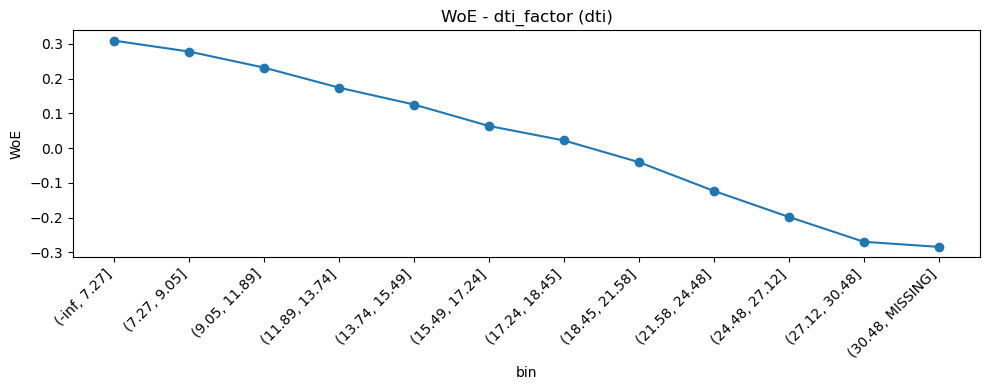

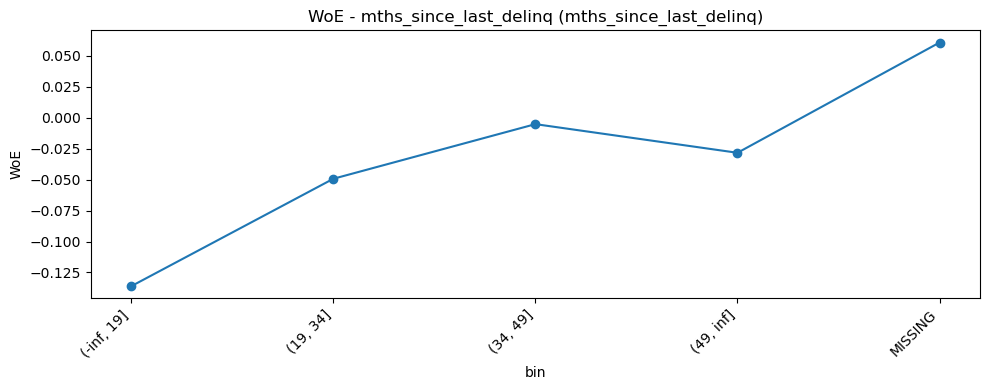

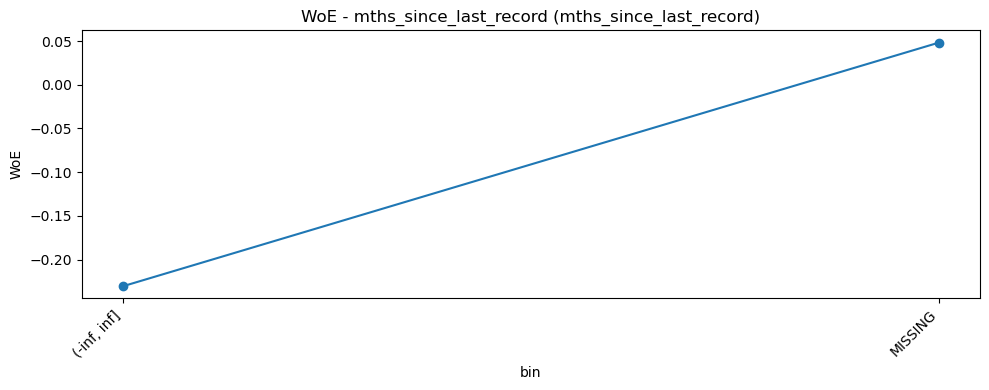

In [7]:
# Optional visual checks
for feat in ["annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record"]:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        plot_by_woe(reports[resolved], title=f'WoE - {feat} ({resolved})')


In [8]:
train_fe_bins = add_all_bin_indicator_columns(train_fe, pipelines, drop_grp_cols=False)
test_fe_bins = add_all_bin_indicator_columns(test_fe, pipelines, drop_grp_cols=False)

In [9]:
train_fe.select("addr_state", *[c for c in train_fe.columns if c.startswith("addr_state")]).show(20, truncate=False)

+----------+----------+--------------------+--------------+---------------------+
|addr_state|addr_state|addr_state__base_grp|addr_state_grp|addr_state_woe       |
+----------+----------+--------------------+--------------+---------------------+
|VA        |VA        |VA                  |VA            |-0.009982305095405512|
|UT        |UT        |UT                  |UT            |0.06860246319891679  |
|VA        |VA        |VA                  |VA            |-0.009982305095405512|
|MO        |MO        |MO                  |MO            |-0.07791920266739873 |
|LA        |LA        |LA                  |LA            |-0.1794568216297773  |
|OR        |OR        |OR                  |OR            |0.34472122251056425  |
|NY        |NY        |NY                  |NY            |-0.10552859072533592 |
|KS        |KS        |KS                  |KS            |0.21352987363692005  |
|CA        |CA        |CA                  |CA            |-0.03418092331144933 |
|PA        |PA  

## 3.5 Save Outputs


In [10]:
drop_cols_train = [
    c for c in train_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]
drop_cols_test = [
    c for c in test_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]

train_fe_bins = train_fe_bins.drop(*drop_cols_train)
test_fe_bins = test_fe_bins.drop(*drop_cols_test)

In [11]:
new_cols_train = [c for c in train_fe_bins.columns if c not in train_df.columns]
new_cols_test = [c for c in test_fe_bins.columns if c not in test_df.columns]

print("New columns in train_fe:")
for c in new_cols_train:
    print(c)

print("\nNew columns in test_fe:")
for c in new_cols_test:
    print(c)

New columns in train_fe:
grade_B
grade_A|MISSING
grade_D
grade_F|G|E
grade_C
home_ownership_OTHER|NONE|RENT
home_ownership_OWN
home_ownership_MORTGAGE|MISSING|2years|ANY
addr_state_919xx|April2009Imovedintomyfirstapartment(noboyfriend
addr_state_StudentLoanNeeded|Advocatebusinessexpansion
addr_state_debt_consolidation
addr_state_SC
addr_state_AZ
addr_state_307xx|BoatLoan
addr_state_OH
addr_state_credit_card
addr_state_TN
addr_state_LA
addr_state_160xx|BreakTheRates
addr_state_NM
addr_state_MN
addr_state_IA
addr_state_internet_$250Food|941xx
addr_state_soPlan""C""istouseaconveniencecheckfromthatcreditcard|980xx
addr_state_PA
addr_state_000+)currentlymanagestherentandmosthouseholdexpendituressoImaypayoffourdebt_Carexpenses_$500Utilities_$150Phone|080xx
addr_state_NJ
addr_state_SD
addr_state_gettingstraight|debts
addr_state_HelpingKenya'sDeafChildren|935xx
addr_state_bridgeloanforsuccessfulmarketingconsultancy|thatIcantakecontrolofmyfinances_Iwillappreciateanyassistancethatisofferedandwil

In [12]:
full_baseline = train_fe_bins.unionByName(test_fe_bins, allowMissingColumns=True)

save_parquet(train_fe_bins, '/home/jovyan/work/data/parquet/features_pd_train.parquet')
save_parquet(test_fe_bins, '/home/jovyan/work/data/parquet/features_pd_test.parquet')
save_parquet(full_baseline, '/home/jovyan/work/data/parquet/features_baseline.parquet')

# Save WoE reports for auditability
for resolved_col, rep in reports.items():
    rep.to_csv(f'/home/jovyan/work/outputs/tables/woe_report_{resolved_col}.csv', index=False)

print('Saved parquet features and WoE report CSV files.')


Saved to /home/jovyan/work/data/parquet/features_pd_train.parquet
Saved to /home/jovyan/work/data/parquet/features_pd_test.parquet
Saved to /home/jovyan/work/data/parquet/features_baseline.parquet
Saved parquet features and WoE report CSV files.
